# Neural Network Model

## Load libraries

In [52]:
# data analysis
import pandas as pd
import numpy as np

# exploratory analysis
import matplotlib.pyplot as plt
import mlxtend
from mlxtend.plotting import scatterplotmatrix
from mlxtend.plotting import heatmap
import seaborn as sns
from IPython.display import Image
import plotly


# Tuning model
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# model fit
import statsmodels.api as sm
import tensorflow as tf

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MultiLabelBinarizer, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# ignore warnings
import warnings
warnings.filterwarnings('ignore')

# better display for dataframes
pd.set_option('display.max_columns', None)

## Step 1: Data Ingestion

In [53]:
# Load splitted dataframes 
X_train = pd.read_csv('X_train.csv')
y_train_unselected = pd.read_csv('y_train.csv')

X_val = pd.read_csv('X_val.csv')
y_val_unselected = pd.read_csv('y_val.csv')

X_test = pd.read_csv('X_test.csv')
y_test_unselected = pd.read_csv('y_test.csv')

# Print dataframes shapes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train_unselected.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"y_val shape: {y_val_unselected.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test_unselected.shape}")


X_train shape: (12426, 345)
y_train shape: (12426, 3)
X_val shape: (4142, 345)
y_val shape: (4142, 3)
X_test shape: (4142, 345)
y_test shape: (4142, 3)


## Step 2: Data Preprocessing
### Only standardization is performed locally , feature engineering is performed in the corresponding notebook.


In [25]:
### Scale the features ###
def get_numerical_features(df, exclude_columns=None):
    """
    Extract all numerical features from a DataFrame, excluding specified columns.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame
    exclude_columns : list, optional
        List of column names to exclude
    
    Returns:
    --------
    list
        List of numerical column names
    """
    # Get all numerical columns
    numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    
    # Remove excluded columns (DATE)
    if exclude_columns:
        numerical_features = [col for col in numerical_features if col not in exclude_columns]
    
    print(f"Found {len(numerical_features)} numerical features")
    
    return numerical_features


# Create copies of the original DataFrames
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

# Exclude DATE column
exclude_columns = ['DATE']
numerical_features = get_numerical_features(X_train, exclude_columns=exclude_columns)

# Standardize the features using StandardScaler
scaler = StandardScaler()
X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_val_scaled[numerical_features] = scaler.transform(X_val[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

'''
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_with_lags)
X_val_scaled = scaler.transform(X_val_with_lags)
X_test_scaled = scaler.transform(X_test_with_lags)
'''

# Verify normalization - calculate means and standard deviations
means = X_train_scaled[numerical_features].mean().mean()
stds = X_train_scaled[numerical_features].std().mean()

print(f"\nStandardization verification:")
print(f"Mean of scaled features (should be close to 0): {means:.6f}")
print(f"Std of scaled features (should be close to 1): {stds:.6f}")

# Show a sample of the normalized data (5 rows, 5 columns)
sample_cols = numerical_features[:5]  # First 5 numerical columns
print("\nSample of scaled data (first 5 rows, 5 columns):")
display(X_train_scaled[sample_cols].head())

Found 312 numerical features

Standardization verification:
Mean of scaled features (should be close to 0): 0.000000
Std of scaled features (should be close to 1): 1.000040

Sample of scaled data (first 5 rows, 5 columns):


,T2M_0401,T2M_MAX_0401,T2M_MIN_0401,QV2M_0401,RH2M_0401
0,-0.408764,-0.132269,-0.498232,0.353499,0.991382
1,-0.095992,0.050615,-0.123490,0.531236,0.843568
2,0.248796,0.372631,0.378556,1.162384,1.121743
3,0.108418,0.278126,0.127533,1.042683,1.211383
4,0.033303,0.280752,0.062984,0.922983,1.145013


## Step 3: Exploratory data analysis (EDA)
### EDA is performed in the corresponding notebook.

## Step 4: Modeling

In [9]:
# Select target variable
target_variable = 'y_3'

# Select target variable
y_train = y_train_unselected[target_variable]
y_val = y_val_unselected[target_variable]
y_test = y_test_unselected[target_variable]


In [54]:
###NN MODEL###
def create_nn_model(input_dim, num_classes):
    # Input layer
    inputs = tf.keras.layers.Input(shape=(input_dim,))
    
    # Reshape for CNN (treating features as a 1D sequence)
    #x = tf.keras.layers.Reshape((input_dim, 1))(inputs)
    
    """     
    # CNN Layers
    # First convolutional block
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=2, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    
    # Second convolutional block
    x = tf.keras.layers.Conv1D(filters=128, kernel_size=2, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    
    # Third convolutional block
    x = tf.keras.layers.Conv1D(filters=256, kernel_size=2, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    x = tf.keras.layers.Dropout(0.1)(x) """
    
    # Dense layers for classification
    x = tf.keras.layers.Dense(256, activation='relu')(inputs)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)
    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.1)(x)

    
    # Output layer
    outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
    
    # Create model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    
    # Compile with AdamW optimizer
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(learning_rate=0.0001, weight_decay=0.0001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Extract unique classes
unique_classes = np.unique(y_train)
print("\nUnique classes:", unique_classes)

# Create the NN model
num_classes = len(unique_classes)
input_dim = X_train_scaled[X_train_scaled.columns.drop('DATE')].shape[1]
nn_model = create_nn_model(input_dim, num_classes)

# Print model summary
nn_model.summary()


Unique classes: [0 1 2 3 4 5 6 7]


Model: "functional_426"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_62 (InputLayer)     │ (None, 344)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_253 (Dense)               │ (None, 256)            │        88,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_191 (Dropout)           │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_254 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_192 (Dropout)           │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_255 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_193 (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,992 (507.78 KB)

 Trainable params: 129,992 (507.78 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
# Calculate class weights 
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=unique_classes,
    y=y_train
)

# Create dictionary mapping class indices to weights
class_weight_dict = {int(class_idx): weight for class_idx, weight in zip(unique_classes, class_weights)}

# Print class weights
print("\nClass weights:")
for class_idx, weight in class_weight_dict.items():
    print(f"  Class {class_idx}: {weight:.4f}")


Class weights:
  Class 0: 0.2989
  Class 1: 0.7837
  Class 2: 0.7282
  Class 3: 2.7443
  Class 4: 1.4019
  Class 5: 4.6091
  Class 6: 1.7452
  Class 7: 7.2582


In [56]:
# Train model
# Add learning rate scheduler to improve convergence
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=0.0001,
    verbose=1
)

# Early stopping to prevent overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# Train the model with class weights
cnn_history = nn_model.fit(
    X_train_scaled[X_train_scaled.columns.drop('DATE')] , 
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_val_scaled[X_val_scaled.columns.drop('DATE')], y_val),
    # class_weight=class_weight_dict,
    callbacks=[
        early_stopping,
        lr_scheduler,
        tf.keras.callbacks.ModelCheckpoint(
            'best_cnn_model.keras',
            monitor='val_loss',
            save_best_only=True,
            verbose=1
        )
    ],
    verbose=1
)

Epoch 1/20
385/389 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4602 - loss: 1.5614
Epoch 1: val_loss improved from inf to 1.43271, saving model to best_cnn_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.4613 - loss: 1.5590 - val_accuracy: 0.5254 - val_loss: 1.4327 - learning_rate: 1.0000e-04
Epoch 2/20
384/389 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6088 - loss: 1.2096
Epoch 2: val_loss improved from 1.43271 to 1.38891, saving model to best_cnn_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.6089 - loss: 1.2094 - val_accuracy: 0.5490 - val_loss: 1.3889 - learning_rate: 1.0000e-04
Epoch 3/20
387/389 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6353 - loss: 1.1647
Epoch 3: val_loss improved from 1.38891 to 1.37443, saving model to best_cnn_model.keras
389/389 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.6353 - loss: 1.1647 - val_accuracy: 0.5543 - val_loss: 1.3744 - learning_rate: 1.0000e-04
Epoch 4/20
386/389 ━━━━━━━━━━━━━━━━━━━━

## Step 5: Experiments

[I 2025-04-14 01:28:02,843] A new study created in memory with name: no-name-86c09869-a659-4955-8835-8c518896d1f4



Epoch 20: ReduceLROnPlateau reducing learning rate to 1.0934077371699477e-05.

Epoch 23: ReduceLROnPlateau reducing learning rate to 4.1135852173930054e-06.

Epoch 26: ReduceLROnPlateau reducing learning rate to 1.5476005783684553e-06.


[I 2025-04-14 01:28:49,619] Trial 0 finished with value: 0.545630156993866 and parameters: {'batch_size': 64, 'n_layers': 3, 'n_units_l0': 388, 'activation_l0': 'relu', 'dropout_l0': 0.17776328510445283, 'n_units_l1': 118, 'activation_l1': 'relu', 'dropout_l1': 0.0763811623471109, 'n_units_l2': 308, 'activation_l2': 'relu', 'dropout_l2': 0.15677053810478897, 'learning_rate': 2.9063222607680525e-05, 'lr_decay_factor': 0.3762169544928192, 'lr_patience': 3}. Best is trial 0 with value: 0.545630156993866.



Epoch 18: ReduceLROnPlateau reducing learning rate to 0.00010964148637641849.


[I 2025-04-14 01:30:00,657] Trial 1 finished with value: 0.49323996901512146 and parameters: {'batch_size': 32, 'n_layers': 5, 'n_units_l0': 148, 'activation_l0': 'elu', 'dropout_l0': 0.08074885021188005, 'n_units_l1': 500, 'activation_l1': 'elu', 'dropout_l1': 0.30514989035551116, 'n_units_l2': 115, 'activation_l2': 'relu', 'dropout_l2': 0.3165467740594939, 'n_units_l3': 35, 'activation_l3': 'selu', 'dropout_l3': 0.13902565279454288, 'n_units_l4': 154, 'activation_l4': 'selu', 'dropout_l4': 0.43402344743653337, 'learning_rate': 0.0003876466402529356, 'lr_decay_factor': 0.282838740569318, 'lr_patience': 7}. Best is trial 0 with value: 0.545630156993866.


...


Epoch 39: ReduceLROnPlateau reducing learning rate to 7.443398784792798e-06.

Epoch 59: ReduceLROnPlateau reducing learning rate to 1.5969278308054043e-06.


[I 2025-04-14 02:25:41,373] Trial 48 finished with value: 0.545630156993866 and parameters: {'batch_size': 64, 'n_layers': 3, 'n_units_l0': 260, 'activation_l0': 'relu', 'dropout_l0': 0.16742587278825205, 'n_units_l1': 55, 'activation_l1': 'relu', 'dropout_l1': 0.43182384650507233, 'n_units_l2': 478, 'activation_l2': 'relu', 'dropout_l2': 0.283142923270266, 'learning_rate': 3.469423267232986e-05, 'lr_decay_factor': 0.21454282911862574, 'lr_patience': 6}. Best is trial 31 with value: 0.5504587292671204.



Epoch 18: ReduceLROnPlateau reducing learning rate to 1.8433895932945686e-05.

Epoch 27: ReduceLROnPlateau reducing learning rate to 5.614144780200108e-06.


[I 2025-04-14 02:27:07,327] Trial 49 finished with value: 0.5465958714485168 and parameters: {'batch_size': 64, 'n_layers': 3, 'n_units_l0': 335, 'activation_l0': 'selu', 'dropout_l0': 0.4707509845499214, 'n_units_l1': 290, 'activation_l1': 'relu', 'dropout_l1': 0.4878580531747319, 'n_units_l2': 485, 'activation_l2': 'relu', 'dropout_l2': 0.2239507780527282, 'learning_rate': 6.052720555579103e-05, 'lr_decay_factor': 0.30455553489180553, 'lr_patience': 6}. Best is trial 31 with value: 0.5504587292671204.


Best trial:
  Value: 0.5504587292671204
  Params:
    batch_size: 128
    n_layers: 3
    n_units_l0: 508
    activation_l0: selu
    dropout_l0: 0.49796887444551813
    n_units_l1: 45
    activation_l1: selu
    dropout_l1: 0.003571962578178628
    n_units_l2: 367
    activation_l2: elu
    dropout_l2: 0.1540127137562558
    learning_rate: 1.3230185409824418e-05
    lr_decay_factor: 0.49956238105043055
    lr_patience: 3
Epoch 1/150
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.1642 - loss: 2.4057
Epoch 1: val_loss improved from inf to 1.92654, saving model to best_optuna_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.1653 - loss: 2.4026 - val_accuracy: 0.3037 - val_loss: 1.9265 - learning_rate: 1.3230e-05
Epoch 2/150
98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3006 - loss: 2.0845
Epoch 2: val_loss improved from 1.92654 to 1.79412, saving model to best_optuna_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3009 - loss: 2.0849 - va

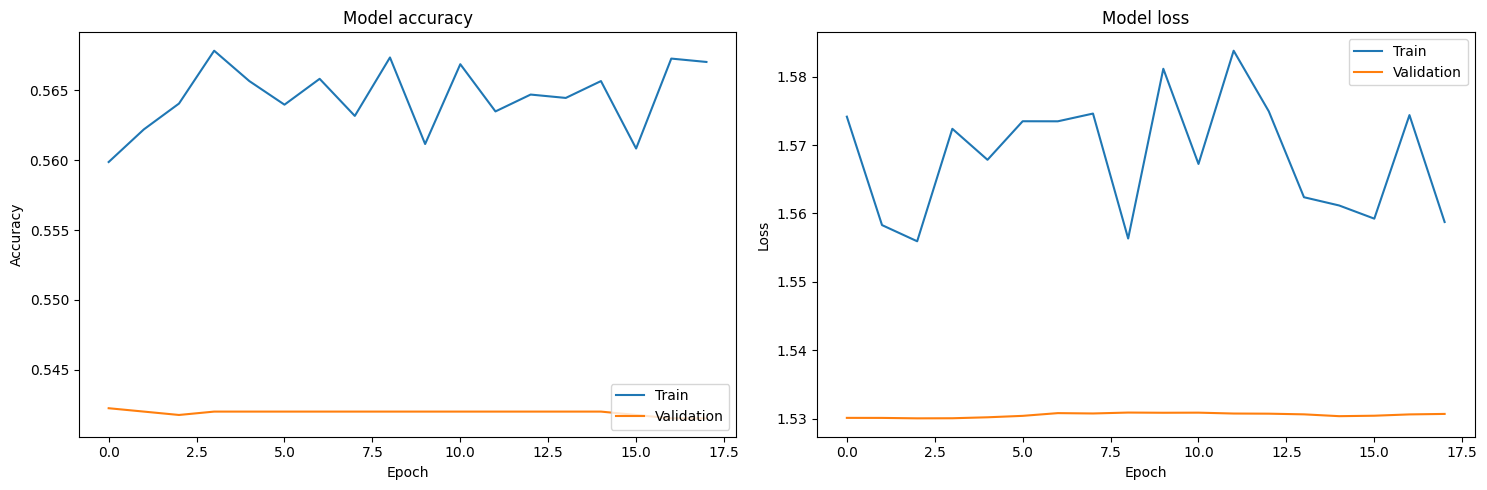

In [33]:
# Create optuna tuning model

def create_model(trial):
    """Create a model with parameters suggested by Optuna"""
    
    # Number of layers (between 2 and 5)
    n_layers = trial.suggest_int('n_layers', 2, 5)
    
    # Create model
    model = Sequential()
    
    # Input layer
    model.add(Input(shape=(344,)))  # Remove DATE column, so 344 features
    
    # Hidden layers
    for i in range(n_layers):
        # Number of units in each layer (decreasing as we go deeper)
        n_units = trial.suggest_int(f'n_units_l{i}', 32, 512)
        
        # Activation function
        activation = trial.suggest_categorical(f'activation_l{i}', 
                                              ['relu', 'elu', 'selu'])
        
        # Add layer
        model.add(Dense(n_units, activation=activation))
        
        # Dropout rate
        dropout_rate = trial.suggest_float(f'dropout_l{i}', 0.0, 0.5)
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))
    
    # Output layer - 8 classes (0-7)
    model.add(Dense(8, activation='softmax'))
    
    # Compile the model
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-2, log=True)
    optimizer = Adam(learning_rate=learning_rate)
    
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

def objective(trial):
    """Objective function for Optuna optimization"""
    
    # Get hyperparameters
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    
    # Create model
    model = create_model(trial)
    
    # Create callbacks
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )
    
    lr_scheduler = ReduceLROnPlateau(
        monitor='val_loss',
        factor=trial.suggest_float('lr_decay_factor', 0.1, 0.5),
        patience=trial.suggest_int('lr_patience', 3, 7),
        min_lr=1e-6,
        verbose=1
    )
    
    # Fit the model - using y_3 (3-day prediction)

    history = model.fit(
        X_train_scaled.drop('DATE', axis=1),
        y_train_unselected['y_3'], 
        epochs=100,
        batch_size=batch_size,
        validation_data=(X_val_scaled.drop('DATE', axis=1), y_val_unselected['y_3']),
        callbacks=[early_stopping, lr_scheduler],
        class_weight=class_weight_dict,  
        verbose=0 
    )
    
    # Return the best validation accuracy
    return history.history['val_accuracy'][-1]

# Create a study object
study = optuna.create_study(direction='maximize')

# Run the optimization
study.optimize(objective, n_trials=50)

# Print the best trial
print('Best trial:')
trial = study.best_trial
print(f'  Value: {trial.value}')
print('  Params:')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

# Train the final model with the best parameters
best_model = create_model(trial)

# Use early stopping and learning rate scheduler
callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=trial.params['lr_decay_factor'],
        patience=trial.params['lr_patience'],
        min_lr=1e-6,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_optuna_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Train the final model 
best_model.fit(
    X_train_scaled.drop('DATE', axis=1),
    y_train_unselected['y_3'],  
    epochs=150,  
    batch_size=trial.params['batch_size'],
    validation_data=(X_val_scaled.drop('DATE', axis=1), y_val_unselected['y_3']),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

# Evaluate on test set
test_loss, test_acc = best_model.evaluate(
    X_test_scaled.drop('DATE', axis=1),
    y_test_unselected['y_3']
)
print(f'Test accuracy: {test_acc:.4f}')

# Save the model
best_model.save('best_fire_prediction_model.keras')

# Generate training plots
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy
    ax1.plot(history.history['accuracy'])
    ax1.plot(history.history['val_accuracy'])
    ax1.set_title('Model accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(['Train', 'Validation'], loc='lower right')
    
    # Loss
    ax2.plot(history.history['loss'])
    ax2.plot(history.history['val_loss'])
    ax2.set_title('Model loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()

# Train with history for plotting
history = best_model.fit(
    X_train_scaled.drop('DATE', axis=1),
    y_train_unselected['y_3'],
    epochs=150,
    batch_size=trial.params['batch_size'],
    validation_data=(X_val_scaled.drop('DATE', axis=1), y_val_unselected['y_3']),
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

plot_history(history)

In [51]:
# Print best parameters
print("Best hyperparameters:")
for key, value in study.best_params.items():
    print(f"    {key}: {value}")

print(f"\nBest validation accuracy: {study.best_value:.4f}")

# Print optimization history
print("\nOptimization history:")
print(f"Number of completed trials: {len(study.trials)}")
best_trials = sorted(study.trials, key=lambda t: t.value, reverse=True)[:5]
print("Top 5 trials:")
for i, trial in enumerate(best_trials):
    print(f"Rank {i+1}: Value: {trial.value:.4f}, Params: {trial.params}")

# Create visualization plots
fig1 = optuna.visualization.plot_optimization_history(study)
fig1.update_layout(title="Optimization History")
fig1.show()

fig2 = optuna.visualization.plot_param_importances(study)
fig2.update_layout(title="Hyperparameter Importance")
fig2.show()

# fig3 = optuna.visualization.plot_contour(study)
# fig3.update_layout(title="Parameter Contour Plot")
# fig3.show()

# # Parallel coordinate plot
# fig4 = optuna.visualization.plot_parallel_coordinate(study)
# fig4.update_layout(title="Parallel Coordinate Plot")
# fig4.show()


Best hyperparameters:
    batch_size: 128
    n_layers: 3
    n_units_l0: 508
    activation_l0: selu
    dropout_l0: 0.49796887444551813
    n_units_l1: 45
    activation_l1: selu
    dropout_l1: 0.003571962578178628
    n_units_l2: 367
    activation_l2: elu
    dropout_l2: 0.1540127137562558
    learning_rate: 1.3230185409824418e-05
    lr_decay_factor: 0.49956238105043055
    lr_patience: 3

Best validation accuracy: 0.5505

Optimization history:
Number of completed trials: 50
Top 5 trials:
Rank 1: Value: 0.5505, Params: {'batch_size': 128, 'n_layers': 3, 'n_units_l0': 508, 'activation_l0': 'selu', 'dropout_l0': 0.49796887444551813, 'n_units_l1': 45, 'activation_l1': 'selu', 'dropout_l1': 0.003571962578178628, 'n_units_l2': 367, 'activation_l2': 'elu', 'dropout_l2': 0.1540127137562558, 'learning_rate': 1.3230185409824418e-05, 'lr_decay_factor': 0.49956238105043055, 'lr_patience': 3}
Rank 2: Value: 0.5490, Params: {'batch_size': 128, 'n_layers': 3, 'n_units_l0': 402, 'activation_l0'

## Step 6: Evaluation and generalization

In [35]:
# Create a model to accept the best parameters found with optuna
def create_optimized_model(input_shape, num_classes, best_params):
    """Create model with the best parameters from Optuna"""
    model = tf.keras.Sequential()
    
    # Input layer
    model.add(tf.keras.layers.Input(shape=(input_shape,)))
    
    # Hidden layers - using best parameters from Optuna
    for i in range(best_params['n_layers']):
        n_units = best_params[f'n_units_l{i}']
        activation = best_params[f'activation_l{i}']
        dropout_rate = best_params[f'dropout_l{i}']
        
        model.add(tf.keras.layers.Dense(n_units, activation=activation))
        if dropout_rate > 0:
            model.add(tf.keras.layers.Dropout(dropout_rate))
    
    # Output layer
    model.add(tf.keras.layers.Dense(num_classes, activation='softmax'))
    
    # Compile model
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=best_params['learning_rate']),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

In [40]:
#Create a function to train the 3, 7 and 14 models 
def train_nn_prediction_models(X_train, X_val, y_train, y_val, best_params,
                               target_cols=['y_3', 'y_7', 'y_14']):
    """
    Train neural network models for multiple fire prediction horizons using best Optuna parameters
    """
    # Prepare data
    X_train_final = X_train.drop('DATE', axis=1, errors='ignore')
    X_val_final = X_val.drop('DATE', axis=1, errors='ignore')
    
    # Dictionary to store results
    training_results = {
        'models': {},
        'class_weights': {},
        'training_info': pd.DataFrame(columns=['Training Time (s)', 'Validation Accuracy']),
        'histories': {},
        'unique_classes': {}
    }
    
    # Train models for each target
    for target in target_cols:
        print(f"\nTraining neural network for {target}...")
        
        # Get target data
        y_train_target = y_train[target]
        y_val_target = y_val[target]
        
        # Get unique classes and class weights
        unique_classes = np.unique(y_train_target)
        class_weights = compute_class_weight(
            class_weight='balanced',
            classes=unique_classes,
            y=y_train_target
        )
        class_weight_dict = {int(class_idx): weight for class_idx, weight in zip(unique_classes, class_weights)}
        
        # Store unique classes and weights
        training_results['unique_classes'][target] = unique_classes
        training_results['class_weights'][target] = class_weight_dict
        
        # Print class distribution and weights
        print(f"  Class distribution:")
        for cls in unique_classes:
            count = np.sum(y_train_target == cls)
            pct = count / len(y_train_target) * 100
            print(f"  Class {cls}: {count} samples ({pct:.2f}%), weight: {class_weight_dict[cls]:.4f}")
        
        # Create model
        input_shape = X_train_final.shape[1]
        num_classes = len(unique_classes)
        model = create_optimized_model(input_shape, num_classes, best_params)
        
        # Create callbacks
        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss',
                patience=10,
                restore_best_weights=True
            ),
            tf.keras.callbacks.ReduceLROnPlateau(
                monitor='val_loss',
                factor=best_params.get('lr_decay_factor', 0.3),
                patience=best_params.get('lr_patience', 5),
                min_lr=1e-6,
                verbose=1
            ),
            tf.keras.callbacks.ModelCheckpoint(
                f'best_nn_model_{target}.keras',
                monitor='val_loss',
                save_best_only=True,
                verbose=1
            )
        ]
        
        # Train model
        import time
        start_time = time.time()
        history = model.fit(
            X_train_final, 
            y_train_target,
            epochs=150,
            batch_size=best_params.get('batch_size', 32),
            validation_data=(X_val_final, y_val_target),
            callbacks=callbacks,
            class_weight=class_weight_dict,
            verbose=1
        )
        train_time = time.time() - start_time
        
        # Calculate validation accuracy
        val_loss, val_accuracy = model.evaluate(X_val_final, y_val_target, verbose=0)
        
        # Store model and training info
        training_results['models'][target] = model
        training_results['histories'][target] = history
        training_results['training_info'].loc[target] = [train_time, val_accuracy]
        
        print(f"  Training completed in {train_time:.2f} seconds")
        print(f"  Best validation accuracy: {val_accuracy:.4f}")
        
    return training_results

In [37]:
# Create a function to evaluate 3, 7 and 14 days mmodels
def evaluate_nn_prediction_models(training_results, X_test, y_test, 
                                 target_cols=['y_3', 'y_7', 'y_14'],
                                 label_dict={0:'No fire',1: '0401', 2:'0402', 3:'0403', 
                                           4:'0404', 5: '0405', 6:'0406', 7:'0407'},
                                 metrics_average='weighted'):
    """
    Evaluate trained neural network models
    (Similar to evaluate_fire_prediction_models but for neural networks)
    """
    # Prepare data
    X_test_final = X_test.drop('DATE', axis=1, errors='ignore')
    
    # Dictionary to store results
    eval_results = {
        'metrics': pd.DataFrame(columns=['Accuracy', 'Precision', 'Recall', 'F1']),
        'predictions': {},
        'figures': {}
    }
    
    # Set up figure for confusion matrices
    confusion_fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Set up figure for training histories
    history_fig, hist_axes = plt.subplots(len(target_cols), 2, figsize=(15, 5*len(target_cols)))
    
    # Evaluate models for each target
    for i, target in enumerate(target_cols):
        print(f"\nEvaluating model for {target}...")
        
        # Get model and test data
        model = training_results['models'][target]
        y_test_target = y_test[target]
        
        # Make predictions
        y_pred_probs = model.predict(X_test_final)
        y_pred = np.argmax(y_pred_probs, axis=1)
        eval_results['predictions'][target] = y_pred
        
        # Calculate metrics
        accuracy = accuracy_score(y_test_target, y_pred)
        precision = precision_score(y_test_target, y_pred, average=metrics_average)
        recall = recall_score(y_test_target, y_pred, average=metrics_average)
        f1 = f1_score(y_test_target, y_pred, average=metrics_average)
        
        # Store metrics
        eval_results['metrics'].loc[target] = [accuracy, precision, recall, f1]
        
        # Print metrics
        print(f"  Accuracy: {accuracy:.4f}")
        print(f"  Precision ({metrics_average}): {precision:.4f}")
        print(f"  Recall ({metrics_average}): {recall:.4f}")
        print(f"  F1 ({metrics_average}): {f1:.4f}")
        
        # Map numeric labels to meaningful names
        y_test_mapped = pd.Series(y_test_target).map(label_dict)
        y_pred_mapped = pd.Series(y_pred).map(label_dict)
        
        # Get unique classes in the order they appear in the label dictionary
        unique_classes = training_results['unique_classes'][target]
        classes_in_data = [label_dict[c] for c in sorted(unique_classes) if c in label_dict]
        
        # Plot confusion matrix
        cm = pd.crosstab(
            y_test_mapped, 
            y_pred_mapped, 
            rownames=['Actual'], 
            colnames=['Predicted'],
            normalize='index' 
        )
        
        # Ensure all classes are represented in the confusion matrix
        for cls in classes_in_data:
            if cls not in cm.index:
                cm.loc[cls] = 0
            if cls not in cm.columns:
                cm[cls] = 0
        
        # Sort the confusion matrix to match the label dictionary order
        cm = cm.loc[classes_in_data][classes_in_data]
        
        # Plot confusion matrix
        sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=axes[i], 
                   cbar=False, annot_kws={"size": 8})
        axes[i].set_title(f'Neural Network: {target.replace("y_", "")} days')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=8)
        axes[i].set_yticklabels(axes[i].get_yticklabels(), fontsize=8)
        
        # Plot training history
        history = training_results['histories'][target]
        
        # Plot accuracy
        if len(target_cols) > 1:
            ax1 = hist_axes[i, 0]
            ax2 = hist_axes[i, 1]
        else:
            ax1 = hist_axes[0]
            ax2 = hist_axes[1]
            
        ax1.plot(history.history['accuracy'])
        ax1.plot(history.history['val_accuracy'])
        ax1.set_title(f'Model accuracy - {target.replace("y_", "")} days')
        ax1.set_ylabel('Accuracy')
        ax1.set_xlabel('Epoch')
        ax1.legend(['Train', 'Validation'], loc='lower right')
        
        # Plot loss
        ax2.plot(history.history['loss'])
        ax2.plot(history.history['val_loss'])
        ax2.set_title(f'Model loss - {target.replace("y_", "")} days')
        ax2.set_ylabel('Loss')
        ax2.set_xlabel('Epoch')
        ax2.legend(['Train', 'Validation'], loc='upper right')
    
    # Add title to confusion matrices
    plt.figure(confusion_fig.number)
    plt.suptitle('Neural Network Fire Prediction Model Comparison', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    eval_results['figures']['confusion'] = confusion_fig
    
    # Finalize training history plot
    plt.figure(history_fig.number)
    plt.tight_layout()
    eval_results['figures']['history'] = history_fig
    
    # Create a comparative metrics chart
    metrics_fig = plt.figure(figsize=(10, 6))
    
    # Rename the index 
    display_metrics = eval_results['metrics'].copy()
    display_metrics.index = [f"{col.replace('y_', '')} Day Forecast" for col in display_metrics.index]
    
    # Plot metrics
    display_metrics.plot(kind='bar', figsize=(10, 5))
    plt.title('Neural Network Model Performance')
    plt.ylabel('Score')
    plt.ylim(0, 1.0)
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)
    plt.legend(loc='upper right')
    
    # Add value labels
    for i, v in enumerate(display_metrics['Accuracy']):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    
    plt.tight_layout()
    eval_results['figures']['metrics'] = metrics_fig
    
    # Create a summary table
    results_table = plt.figure(figsize=(10, 3))
    plt.axis('off')
    
    # Add a table with key metrics
    table_data = eval_results['metrics'].round(3)
    table_data.index = [f"{col.replace('y_', '')} Day Forecast" for col in table_data.index]
    
    # Create the table
    table = plt.table(
        cellText=table_data.values,
        rowLabels=table_data.index,
        colLabels=table_data.columns,
        cellLoc='center',
        loc='center',
        bbox=[0, 0, 1, 1]
    )
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.5)
    
    # Add a title
    plt.title('Neural Network Performance Metrics Summary', pad=20, fontsize=14)
    eval_results['figures']['table'] = results_table
    
    return eval_results

In [41]:
# Get the best parameters from Optuna
'''
Params:
batch_size: 128
n_layers: 3
n_units_l0: 508
activation_l0: selu
dropout_l0: 0.49796887444551813
n_units_l1: 45
activation_l1: selu
dropout_l1: 0.003571962578178628
n_units_l2: 367
activation_l2: elu
dropout_l2: 0.1540127137562558
learning_rate: 1.3230185409824418e-05
lr_decay_factor: 0.49956238105043055
lr_patience: 3
'''
best_params = {
    'n_layers': 3,                   # Number of layers
    'n_units_l0': 508,               # Units in first layer
    'activation_l0': 'selu',         # Activation function in first layer
    'dropout_l0': 0.5,               # Dropout rate in first layer
    'n_units_l1': 45,               # Units in second layer
    'activation_l1': 'selu',         # Activation function in second layer
    'dropout_l1': 0.0036,               # Dropout rate in second layer
    'n_units_l2': 367,                # Units in third layer
    'activation_l2': 'elu',         # Activation function in third layer
    'dropout_l2': 0.154,               # Dropout rate in third layer
    'learning_rate': 1.323e-05,          # Learning rate
    'batch_size': 128,                # Batch size
    'lr_decay_factor': 0.5,          # Learning rate decay factor
    'lr_patience': 3                 # Learning rate patience
}

# Train the neural network models for each prediction horizon
training_results = train_nn_prediction_models(
    X_train_scaled, X_val_scaled, 
    y_train_unselected, y_val_unselected,
    best_params,
    target_cols=['y_3', 'y_7', 'y_14']
)


Training neural network for y_3...
  Class distribution:
  Class 0: 5196 samples (41.82%), weight: 0.2989
  Class 1: 1982 samples (15.95%), weight: 0.7837
  Class 2: 2133 samples (17.17%), weight: 0.7282
  Class 3: 566 samples (4.55%), weight: 2.7443
  Class 4: 1108 samples (8.92%), weight: 1.4019
  Class 5: 337 samples (2.71%), weight: 4.6091
  Class 6: 890 samples (7.16%), weight: 1.7452
  Class 7: 214 samples (1.72%), weight: 7.2582
Epoch 1/150
96/98 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1832 - loss: 2.3231
Epoch 1: val_loss improved from inf to 1.87189, saving model to best_nn_model_y_3.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.1844 - loss: 2.3204 - val_accuracy: 0.3247 - val_loss: 1.8719 - learning_rate: 1.3230e-05
Epoch 2/150
92/98 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3274 - loss: 2.0811
Epoch 2: val_loss improved from 1.87189 to 1.76838, saving model to best_nn_model_y_3.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3287 - loss:


Evaluating model for y_3...
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  Accuracy: 0.5080
  Precision (weighted): 0.5308
  Recall (weighted): 0.5080
  F1 (weighted): 0.5167

Evaluating model for y_7...
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
  Accuracy: 0.3670
  Precision (weighted): 0.4170
  Recall (weighted): 0.3670
  F1 (weighted): 0.3812

Evaluating model for y_14...
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
  Accuracy: 0.2574
  Precision (weighted): 0.3282
  Recall (weighted): 0.2574
  F1 (weighted): 0.2753

Neural Network Model Performance Summary:
      Accuracy  Precision  Recall     F1
y_3      0.508      0.531   0.508  0.517
y_7      0.367      0.417   0.367  0.381
y_14     0.257      0.328   0.257  0.275


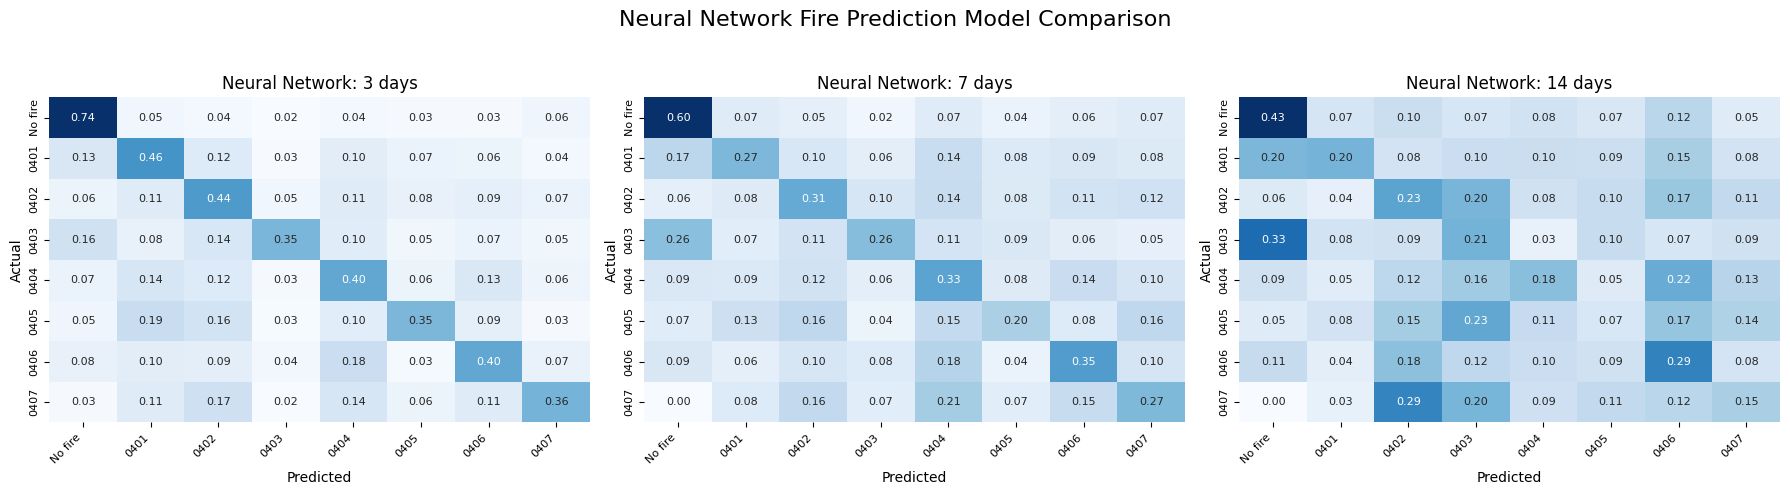

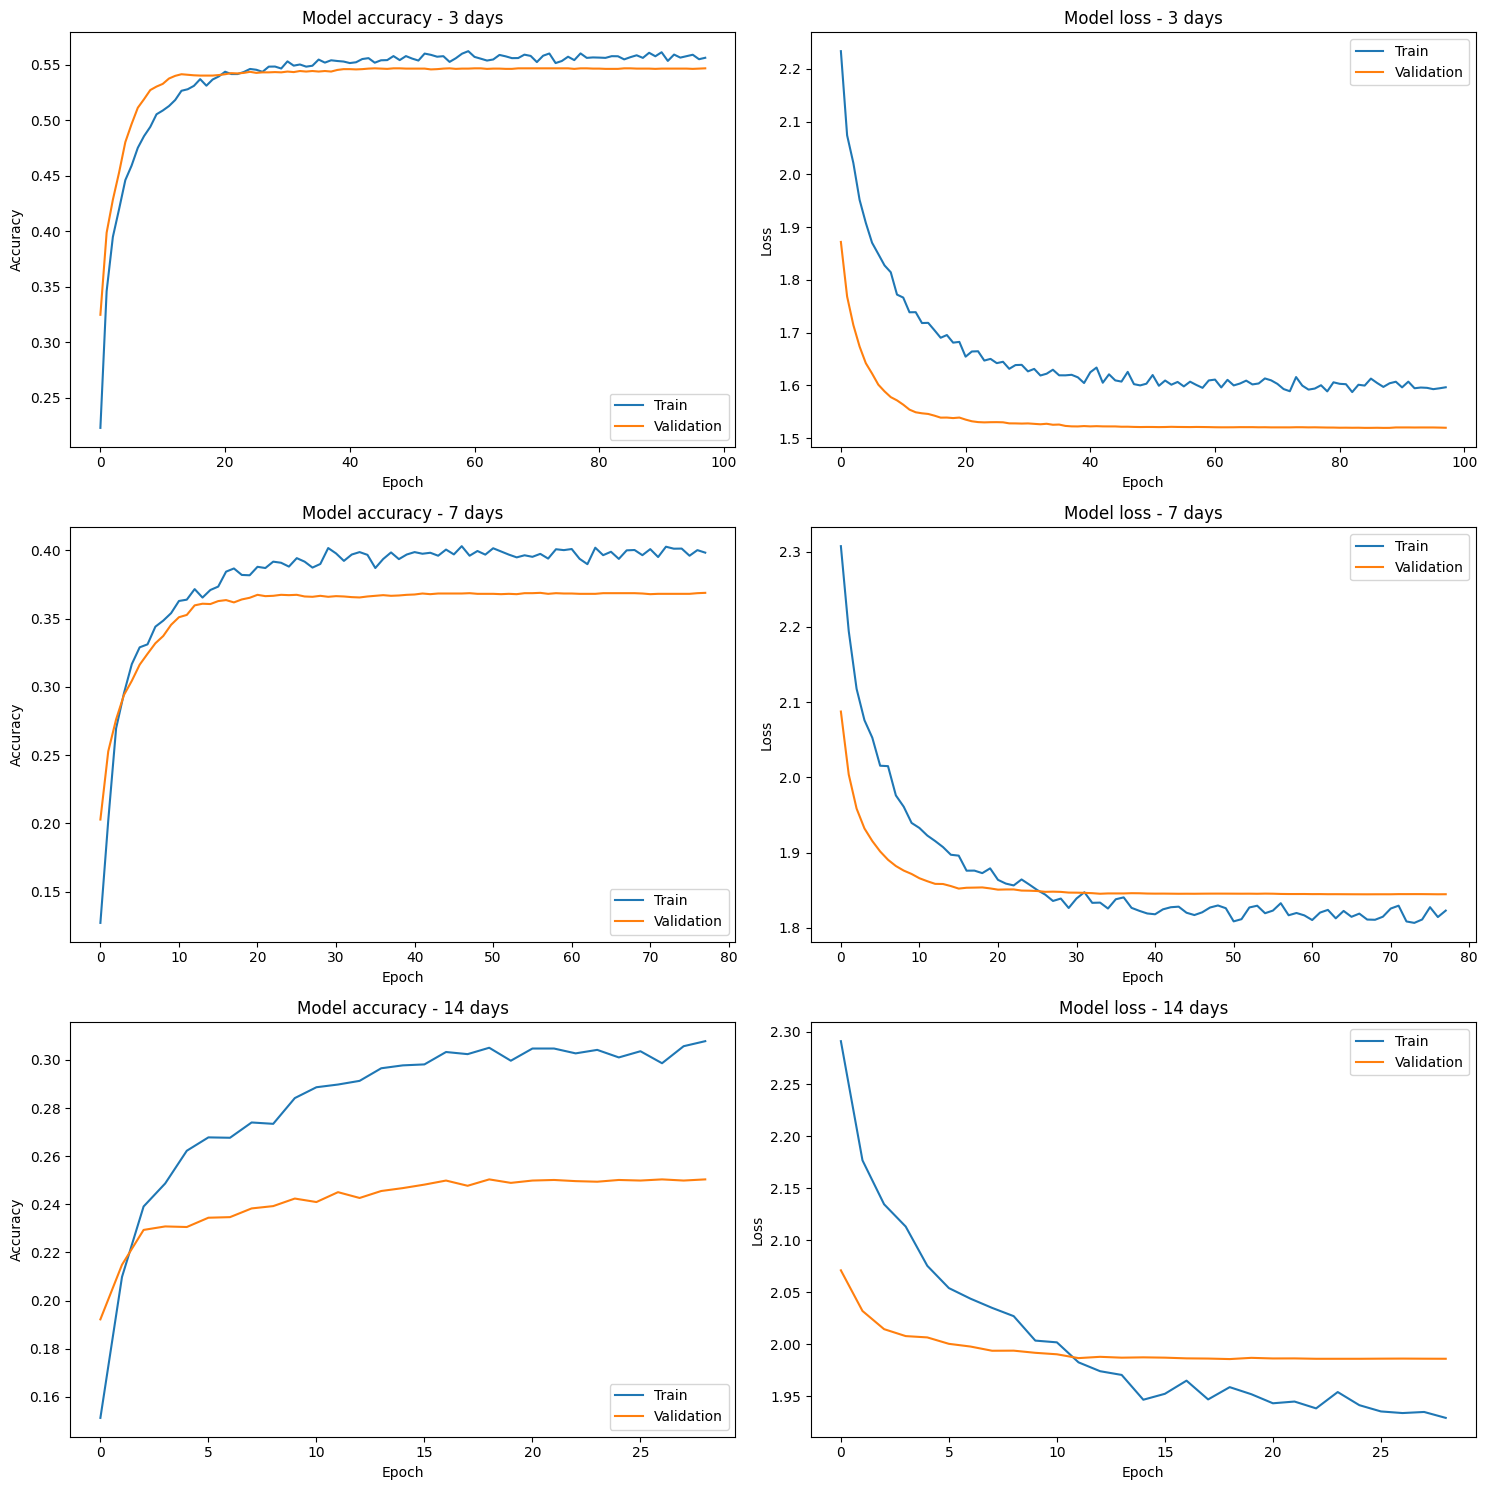

<Figure size 1000x600 with 0 Axes>

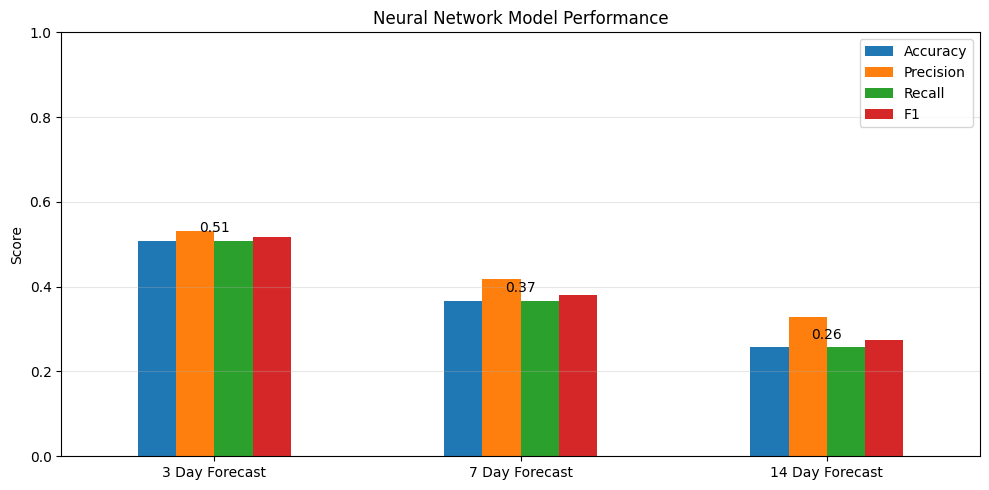

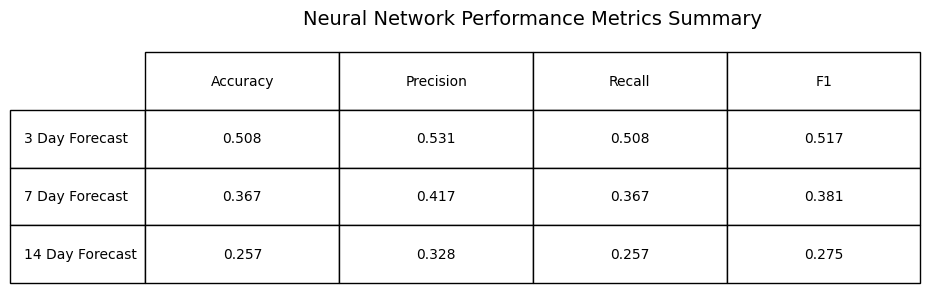

In [43]:
# Evaluate the neural network models
eval_results = evaluate_nn_prediction_models(
    training_results, 
    X_test_scaled, y_test_unselected,
    target_cols=['y_3', 'y_7', 'y_14'],
    label_dict={0:'No fire',1: '0401', 2:'0402', 3:'0403', 4:'0404',5: '0405', 6:'0406', 7:'0407'},
    metrics_average='weighted' 
)

# Display figures
eval_results['figures']['confusion'].show()
eval_results['figures']['metrics'].show()
eval_results['figures']['table'].show()
eval_results['figures']['history'].show()

# Print summary
print("\nNeural Network Model Performance Summary:")
print(eval_results['metrics'].round(3))